In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"/kaggle/input/nutrition-facts/menu.csv")

In [3]:
df.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 260 entries, 0 to 259
,Data columns (total 24 columns):
, #   Column                         Non-Null Count  Dtype  
,---  ------                         --------------  -----  
, 0   Category                       260 non-null    object 
, 1   Item                           260 non-null    object 
, 2   Serving Size                   260 non-null    object 
, 3   Calories                       260 non-null    int64  
, 4   Calories from Fat              260 non-null    int64  
, 5   Total Fat                      260 non-null    float64
, 6   Total Fat (% Daily Value)      260 non-null    int64  
, 7   Saturated Fat                  260 non-null    float64
, 8   Saturated Fat (% Daily Value)  260 non-null    int64  
, 9   Trans Fat                      260 non-null    float64
, 10  Cholesterol                    260 non-null    int64  
, 11  Cholesterol (% Daily Value)    260 non-null    int64  
, 12  Sodium                         26

In [5]:
df.isnull().sum()

Category                         0
Item                             0
Serving Size                     0
Calories                         0
Calories from Fat                0
Total Fat                        0
Total Fat (% Daily Value)        0
Saturated Fat                    0
Saturated Fat (% Daily Value)    0
Trans Fat                        0
Cholesterol                      0
Cholesterol (% Daily Value)      0
Sodium                           0
Sodium (% Daily Value)           0
Carbohydrates                    0
Carbohydrates (% Daily Value)    0
Dietary Fiber                    0
Dietary Fiber (% Daily Value)    0
Sugars                           0
Protein                          0
Vitamin A (% Daily Value)        0
Vitamin C (% Daily Value)        0
Calcium (% Daily Value)          0
Iron (% Daily Value)             0
dtype: int64

In [6]:
df.describe()

,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


In [7]:
cols = ['Calories', 'Calories from Fat','Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat','Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol','Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)','Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber','Dietary Fiber (% Daily Value)', 'Sugars', 'Protein','Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)','Calcium (% Daily Value)', 'Iron (% Daily Value)']

for col in cols:
    skew_series = df[cols].skew().sort_values(ascending=False)
print(skew_series)

Vitamin C (% Daily Value)        5.502231
,Vitamin A (% Daily Value)        4.580331
,Cholesterol (% Daily Value)      3.804200
,Cholesterol                      3.798907
,Total Fat (% Daily Value)        2.162011
,Total Fat                        2.152799
,Calories from Fat                2.145508
,Trans Fat                        2.135819
,Protein                          1.579924
,Sodium (% Daily Value)           1.545986
,Sodium                           1.544088
,Calories                         1.452498
,Iron (% Daily Value)             1.187908
,Dietary Fiber                    1.173625
,Dietary Fiber (% Daily Value)    1.154245
,Sugars                           1.031940
,Carbohydrates                    0.912699
,Carbohydrates (% Daily Value)    0.903599
,Saturated Fat (% Daily Value)    0.685296
,Saturated Fat                    0.663685
,Calcium (% Daily Value)          0.593555
,dtype: float64


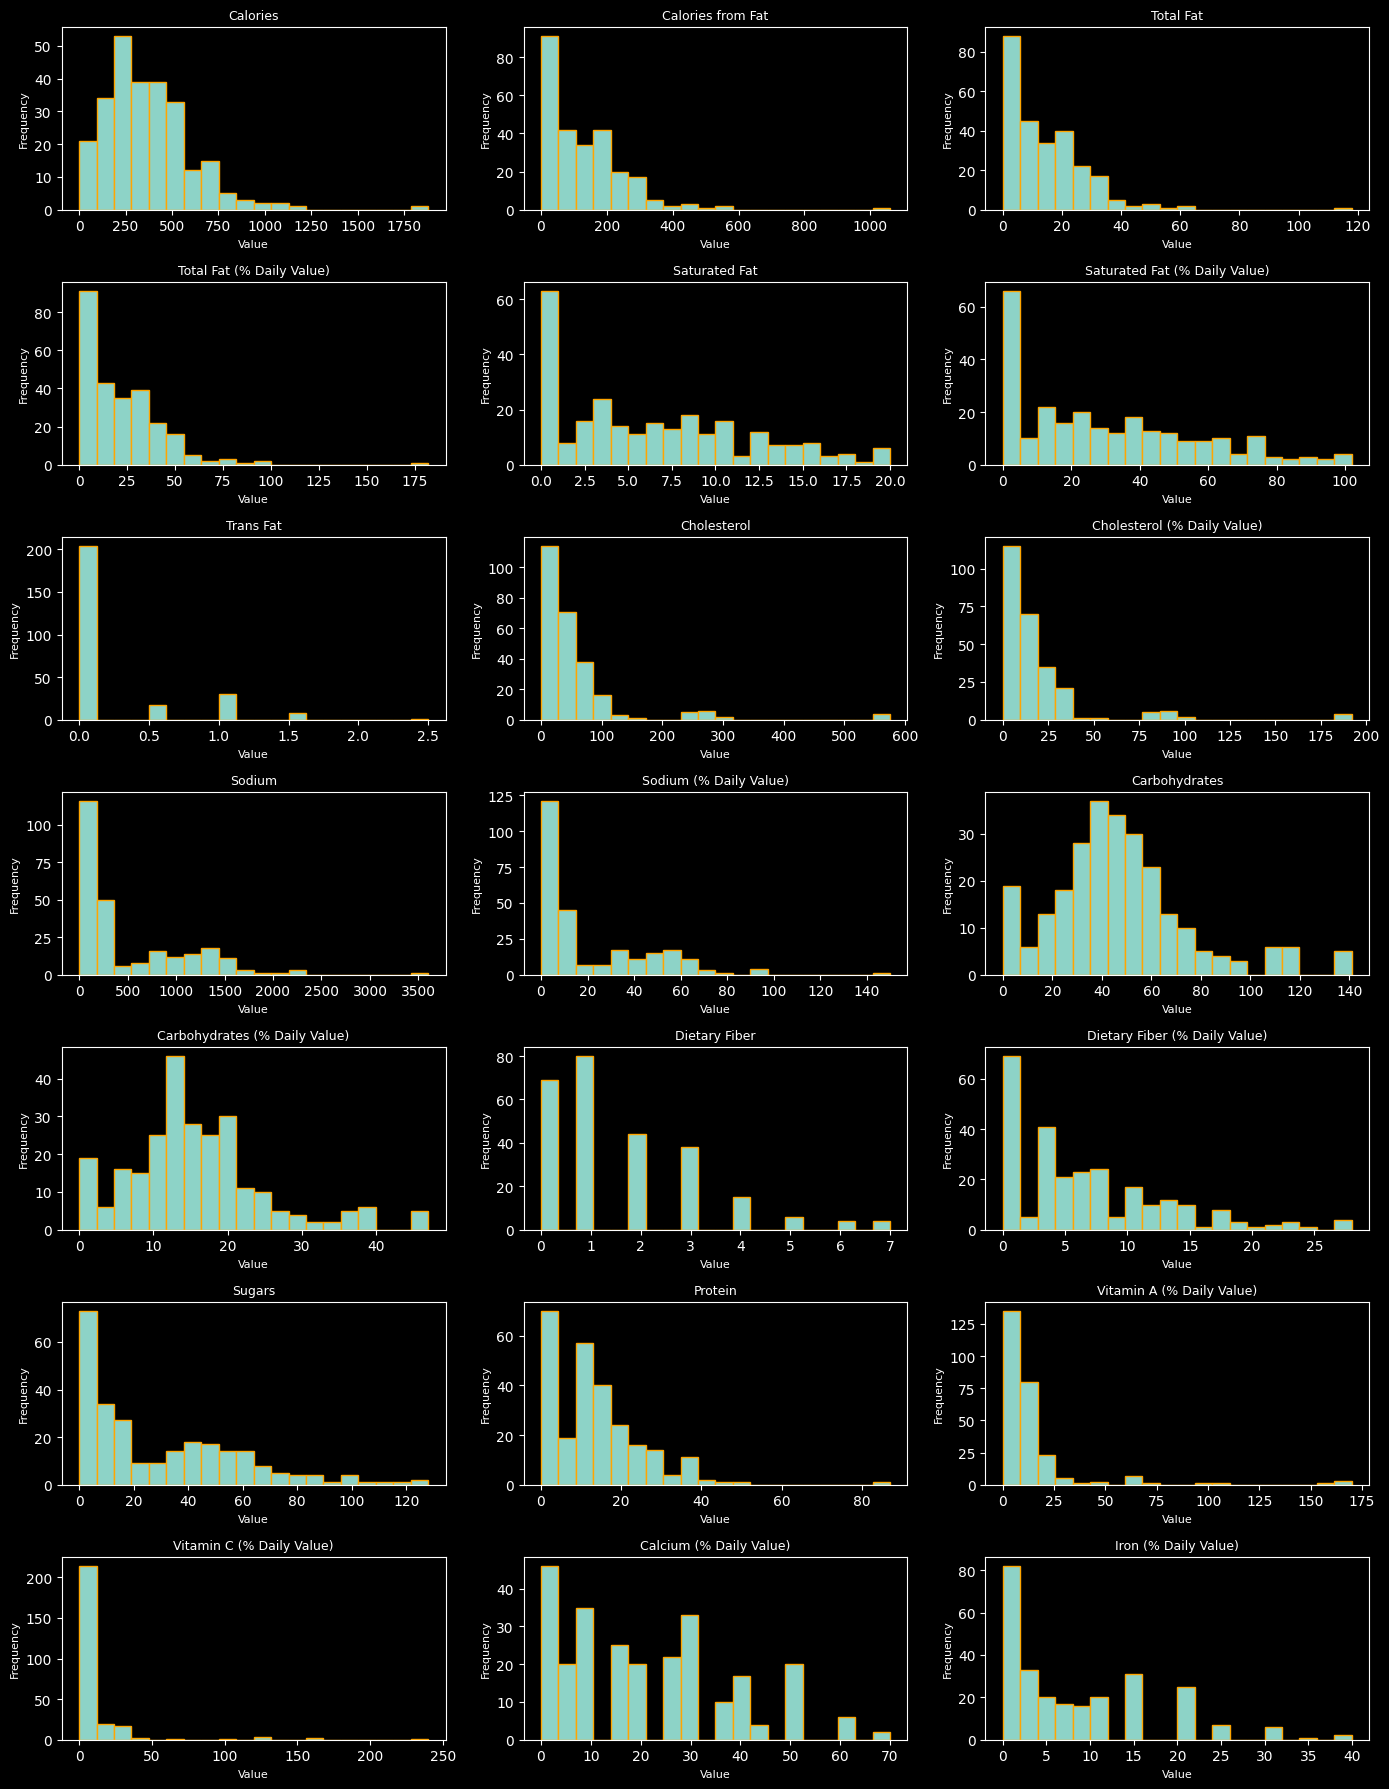

In [8]:
cols = ['Calories', 'Calories from Fat','Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat','Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol','Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)','Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber','Dietary Fiber (% Daily Value)', 'Sugars', 'Protein','Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)','Calcium (% Daily Value)', 'Iron (% Daily Value)']
plt.style.use("dark_background")

fig, axes = plt.subplots(7, 3, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, edgecolor='orange')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Value", fontsize=8)
    axes[i].set_ylabel("Frequency", fontsize=8)

plt.tight_layout()
plt.show()

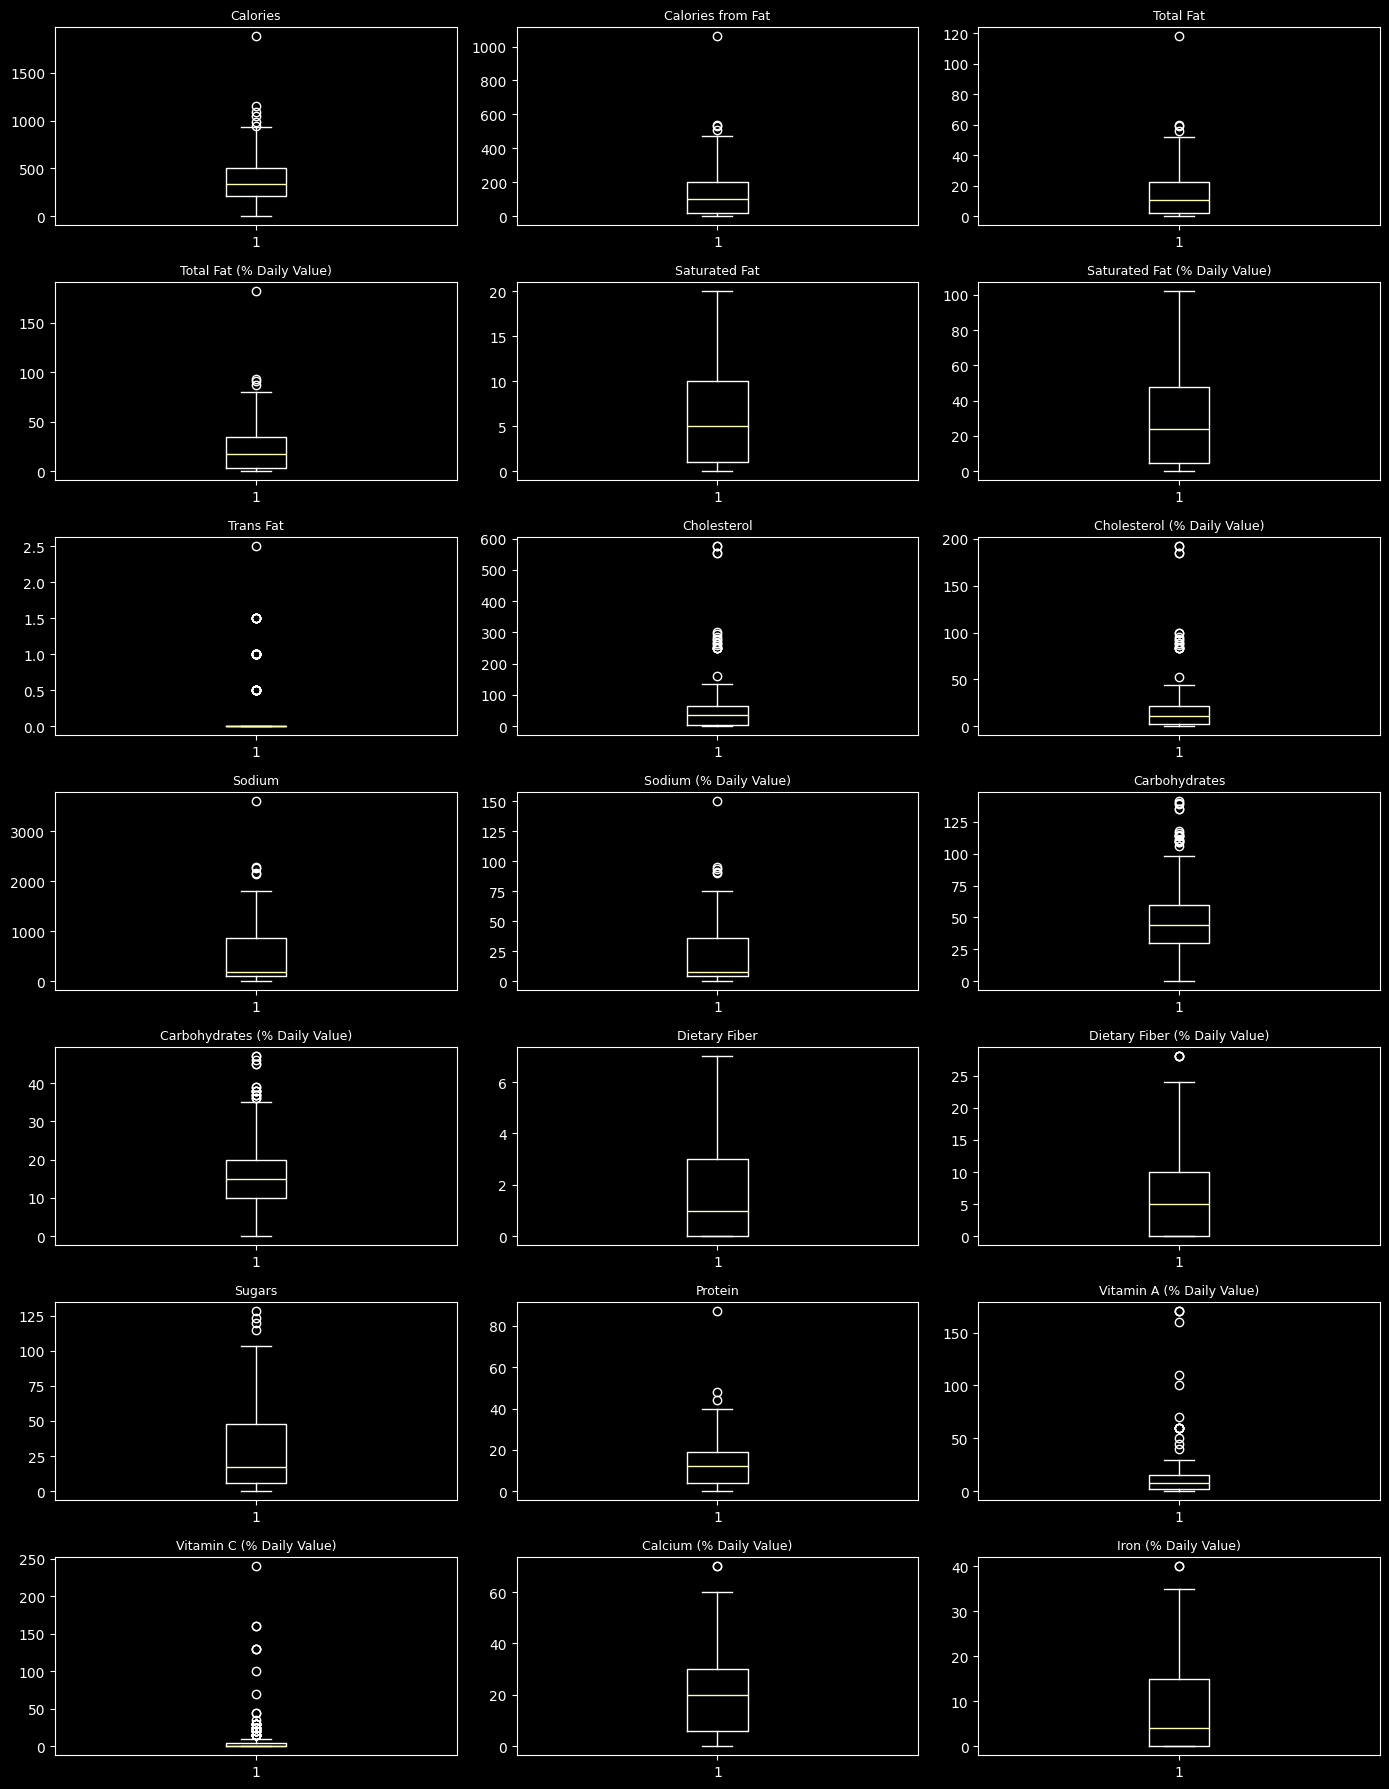

In [9]:
cols = ['Calories', 'Calories from Fat','Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat','Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol','Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)','Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber','Dietary Fiber (% Daily Value)', 'Sugars', 'Protein','Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)','Calcium (% Daily Value)', 'Iron (% Daily Value)']
fig, axes = plt.subplots(7,3,figsize=(14,18))
axes = axes.flatten()

for i,col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(False)
    #axes[i].x_label(col, fontsize=8)
    #axes[i].y_label("frequency", fontsize=8)
plt.tight_layout()
plt.style.use("dark_background")
plt.show()

In [10]:
df[df['Calories from Fat'] > 1000]

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
82,Chicken & Fish,Chicken McNuggets (40 piece),22.8 oz (646 g),1880,1060,118.0,182,20.0,101,1.0,...,118,39,6,24,1,87,0,15,8,25


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Breakfast'),
  Text(1, 0, 'Beef & Pork'),
  Text(2, 0, 'Chicken & Fish'),
  Text(3, 0, 'Salads'),
  Text(4, 0, 'Snacks & Sides'),
  Text(5, 0, 'Desserts'),
  Text(6, 0, 'Beverages'),
  Text(7, 0, 'Coffee & Tea'),
  Text(8, 0, 'Smoothies & Shakes')])

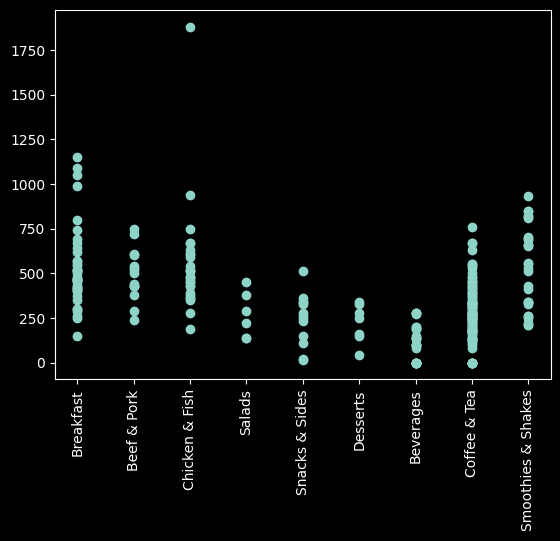

In [11]:
plt.scatter(df['Category'],df['Calories'])
plt.xticks(rotation=90)

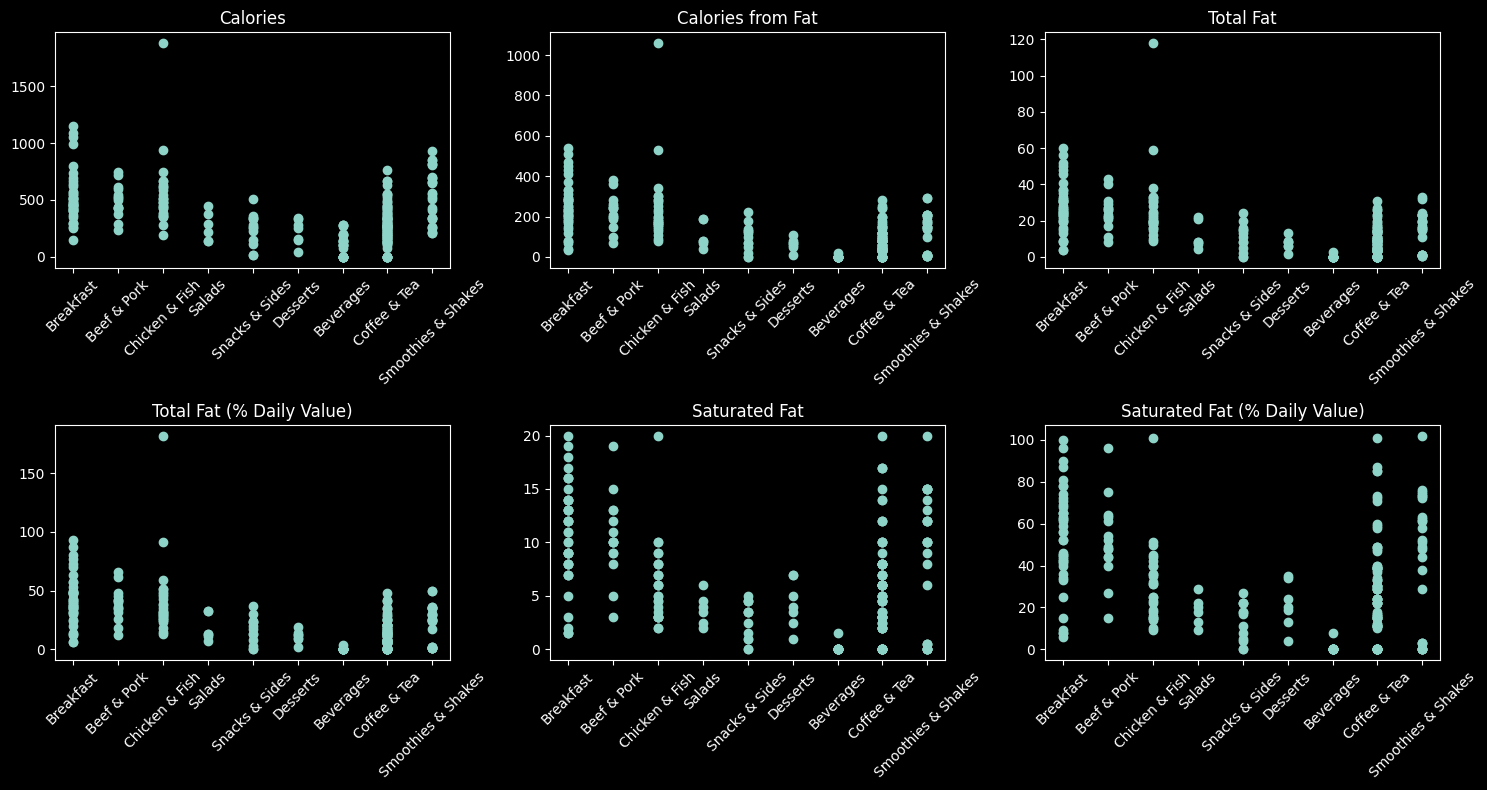

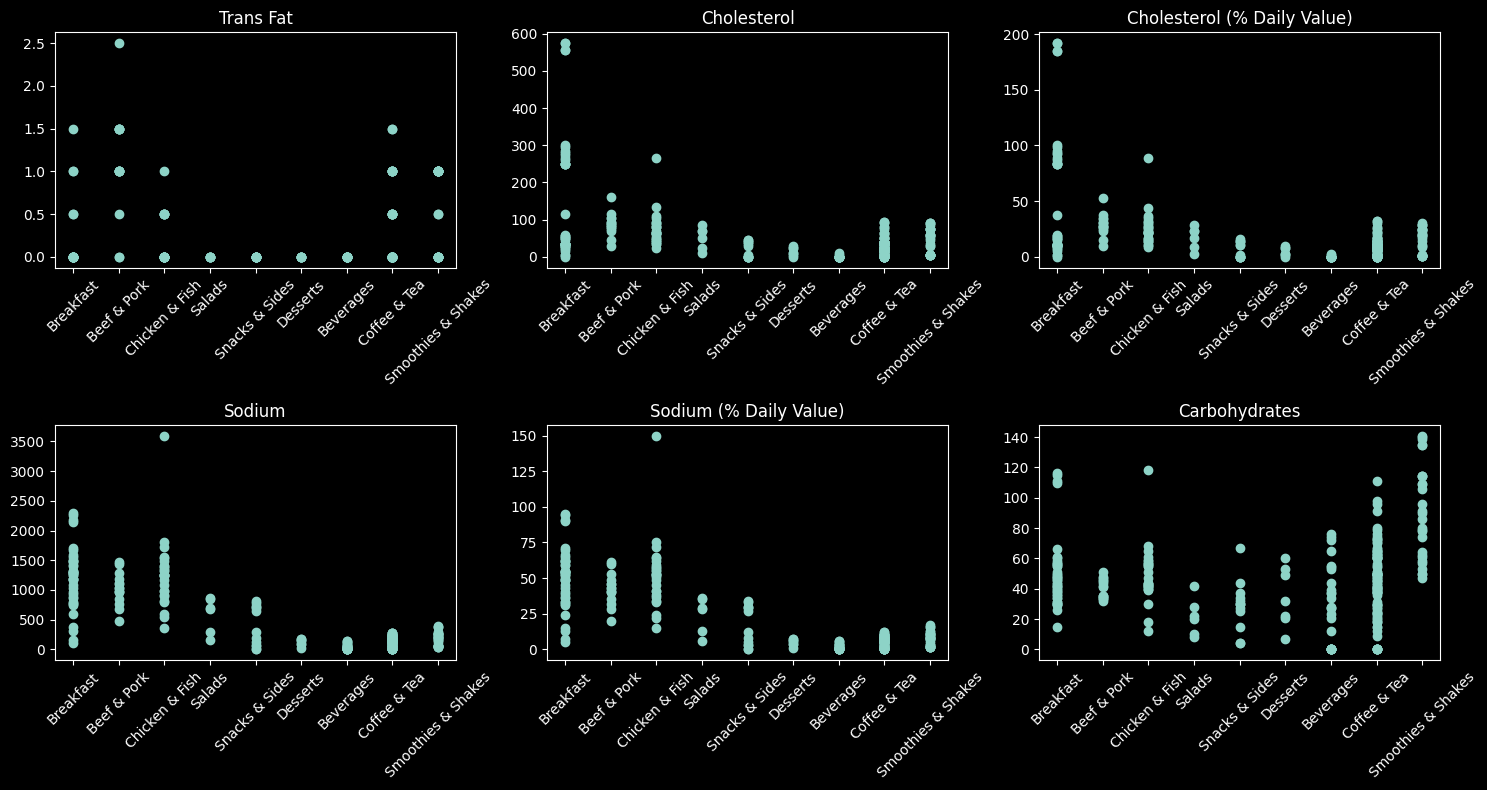

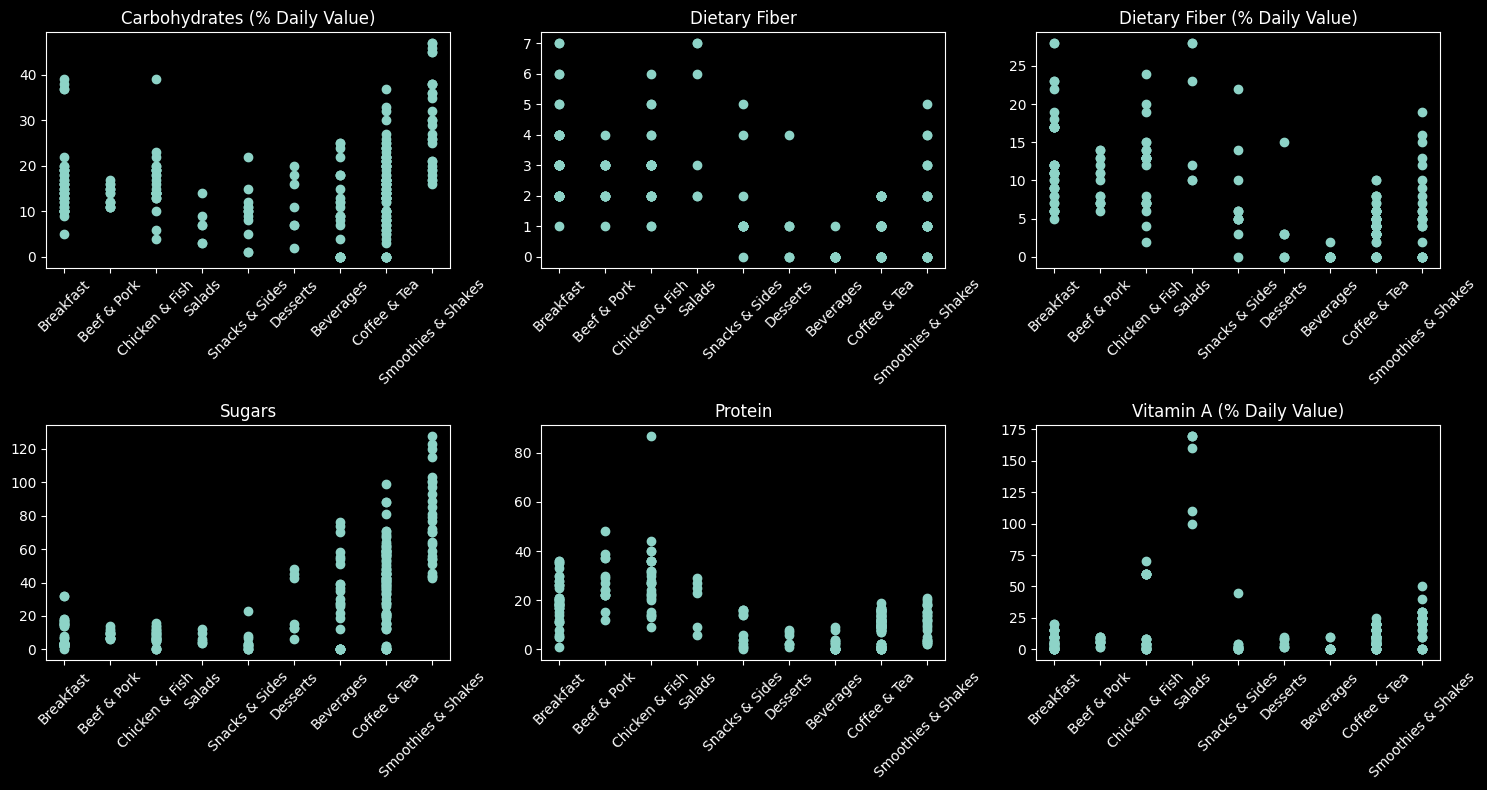

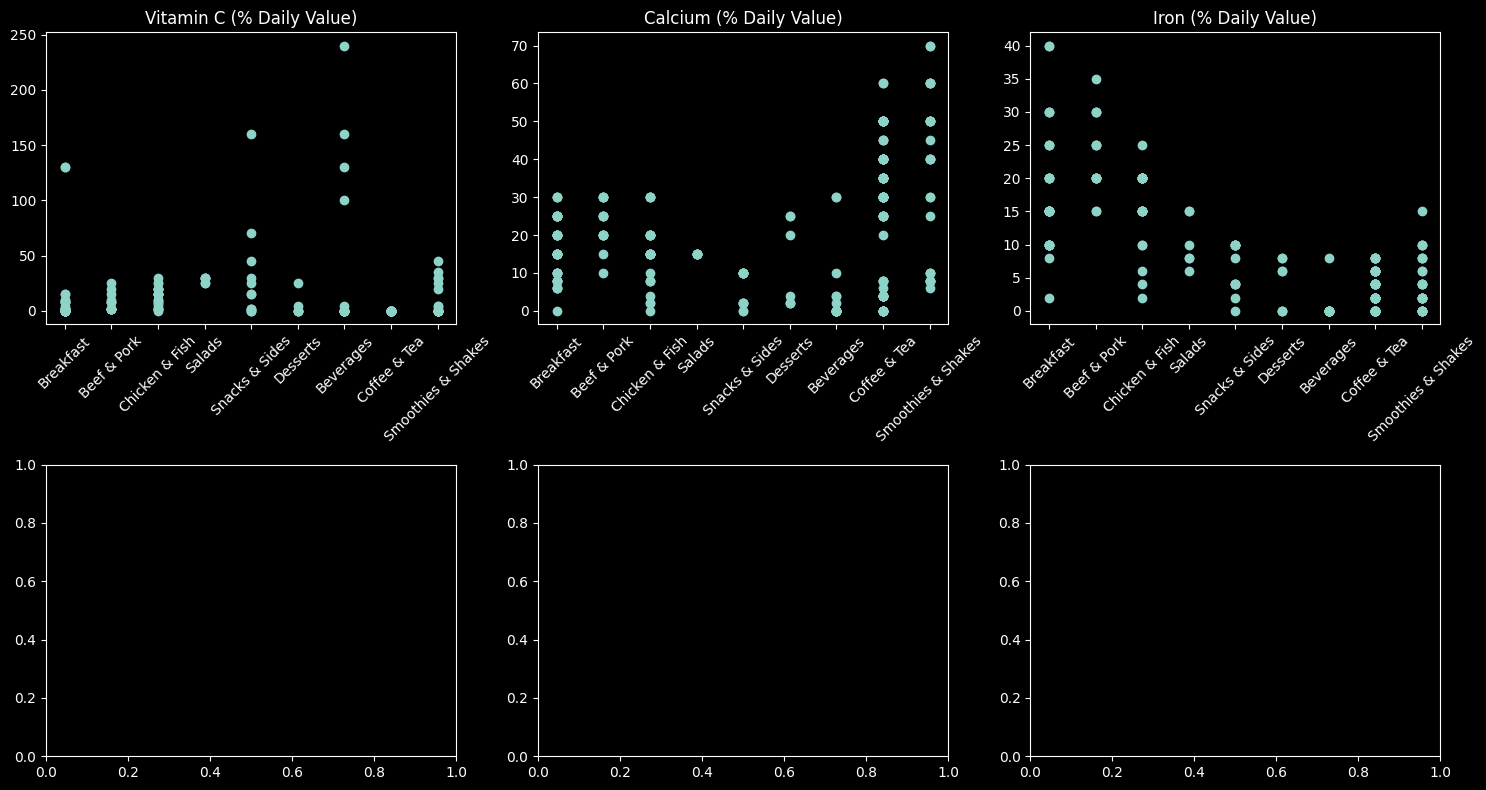

In [12]:
cols = ['Calories', 'Calories from Fat','Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat','Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol','Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)','Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber','Dietary Fiber (% Daily Value)', 'Sugars', 'Protein','Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)','Calcium (% Daily Value)', 'Iron (% Daily Value)']

plt.style.use("dark_background")

for start in range(0, len(cols), 6):
    subset_cols = cols[start:start+6]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(subset_cols):
        axes[i].scatter(df['Category'], df[col])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

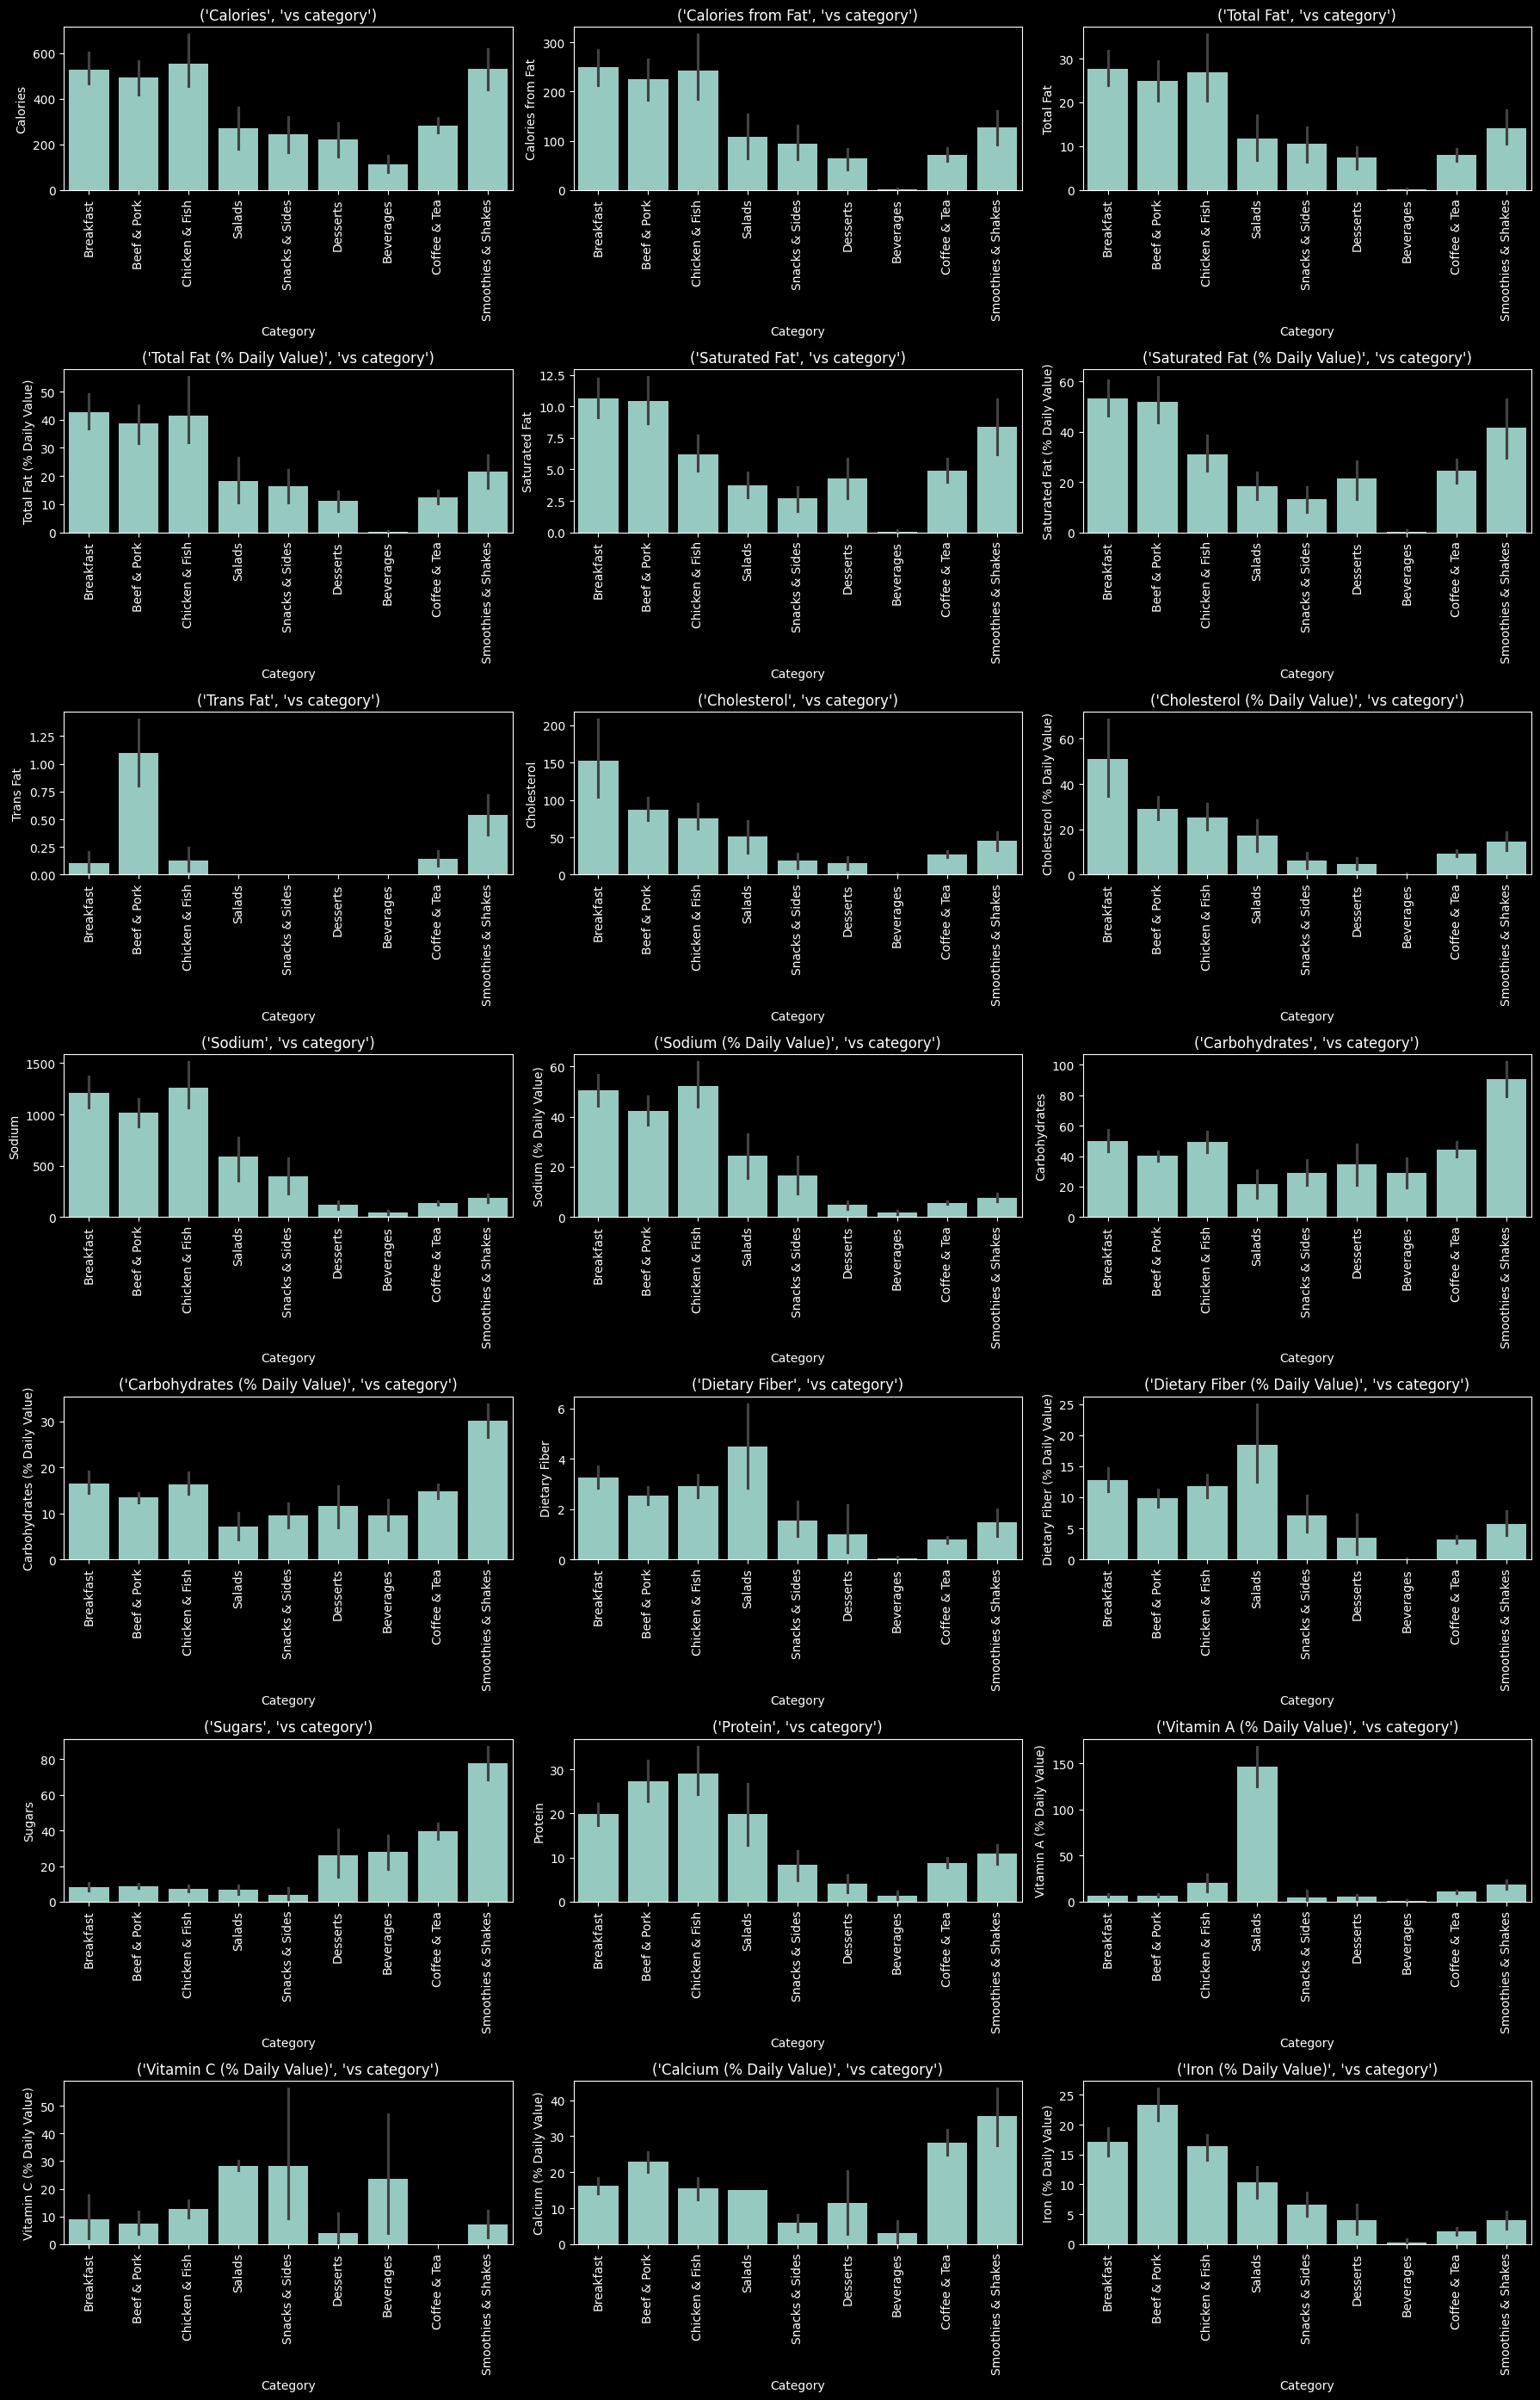

In [13]:
cols = ['Calories', 'Calories from Fat','Total Fat', 'Total Fat (% Daily Value)', 'Saturated Fat','Saturated Fat (% Daily Value)', 'Trans Fat', 'Cholesterol','Cholesterol (% Daily Value)', 'Sodium', 'Sodium (% Daily Value)','Carbohydrates', 'Carbohydrates (% Daily Value)', 'Dietary Fiber','Dietary Fiber (% Daily Value)', 'Sugars', 'Protein','Vitamin A (% Daily Value)', 'Vitamin C (% Daily Value)','Calcium (% Daily Value)', 'Iron (% Daily Value)']

plt.style.use("dark_background")

fig, axes = plt.subplots(7, 3, figsize=(18, 28))
axes = axes.flatten()   # convert 2D array to 1D

for i, col in enumerate(cols):
    sns.barplot(x='Category', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col,"vs category"}')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [14]:
df['Grams'] = df['Serving Size'].str.extract(r'\((\d+\.?\d*)\s*g\)')
df['Cups'] = df['Serving Size'].str.extract(r'(\d+\.?\d*)\s*fl\s*oz')

In [15]:
df['Grams'] = df['Grams'].fillna(0)
df['Cups'] = df['Cups'].fillna(0)

In [16]:
df.drop(columns=['Serving Size'], inplace=True)

In [17]:
df['Category'] = df['Category'].map({'Coffee & Tea':0,'Breakfast':1,'Smoothies & Shakes':2,'Chicken & Fish':3,'Beverages':4,'Beef & Pork':5,'Snacks & Sides':6,'Desserts':7,'Salads':8})

In [18]:
df['Item']

0                                           Egg McMuffin
1                                      Egg White Delight
2                                       Sausage McMuffin
3                              Sausage McMuffin with Egg
4                       Sausage McMuffin with Egg Whites
                             ...                        
255                   McFlurry with Oreo Cookies (Small)
256                  McFlurry with Oreo Cookies (Medium)
257                   McFlurry with Oreo Cookies (Snack)
258    McFlurry with Reese's Peanut Butter Cups (Medium)
259     McFlurry with Reese's Peanut Butter Cups (Snack)
Name: Item, Length: 260, dtype: object

In [19]:
df['Item'].nunique()

260

In [20]:
df['Size'] = df['Item'].str.extract(r'\((.*?)\)')

In [21]:
df['Is_Burger'] = df['Item'].str.contains('Burger|Quarter Pounder|Big Mac', case=False).astype(int)
df['Is_Chicken'] = df['Item'].str.contains('Chicken', case=False).astype(int)
df['Is_Drink'] = df['Item'].str.contains('Coffee|Latte|Coke|Tea|Smoothie|Shake', case=False).astype(int)
df['Is_Dessert'] = df['Item'].str.contains('McFlurry|Cookie|Pie|Sundae', case=False).astype(int)

In [22]:
df['Base_Item'] = df['Item'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

In [23]:
df['Size'] = df['Size'].fillna(0)

In [24]:
df = pd.get_dummies(df, columns=['Size'])

In [25]:
df.shape

(260, 46)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 260 entries, 0 to 259
,Data columns (total 46 columns):
, #   Column                         Non-Null Count  Dtype  
,---  ------                         --------------  -----  
, 0   Category                       260 non-null    int64  
, 1   Item                           260 non-null    object 
, 2   Calories                       260 non-null    int64  
, 3   Calories from Fat              260 non-null    int64  
, 4   Total Fat                      260 non-null    float64
, 5   Total Fat (% Daily Value)      260 non-null    int64  
, 6   Saturated Fat                  260 non-null    float64
, 7   Saturated Fat (% Daily Value)  260 non-null    int64  
, 8   Trans Fat                      260 non-null    float64
, 9   Cholesterol                    260 non-null    int64  
, 10  Cholesterol (% Daily Value)    260 non-null    int64  
, 11  Sodium                         260 non-null    int64  
, 12  Sodium (% Daily Value)         26

In [27]:
df = pd.get_dummies(df, columns=['Base_Item'])

In [28]:
df = df.drop(columns=['Item'])

In [29]:
df = df.astype('float64')

In [30]:
skewed_cols = df.skew()[df.skew() > 3].index

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [31]:
df.corr(method='pearson')

,Category,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),...,Base_Item_Southern Style Crispy Chicken Sandwich,Base_Item_Sprite,Base_Item_Steak & Egg Biscuit,Base_Item_Steak & Egg McMuffin,"Base_Item_Steak, Egg & Cheese Bagel",Base_Item_Strawberry Banana Smoothie,Base_Item_Strawberry Shake,Base_Item_Strawberry Sundae,Base_Item_Sweet Tea,Base_Item_Vanilla Shake
Category,1.000000,-0.062974,0.022112,0.018596,0.019300,-0.136257,-0.135115,0.072709,-0.143345,-0.123554,...,0.026073,0.108571,-0.029721,-0.029721,-0.029721,-0.003172,-0.003172,0.137662,-0.115910,-0.003172
Calories,-0.062974,1.000000,0.904588,0.904409,0.904123,0.845564,0.847631,0.522441,0.719668,0.738124,...,0.015995,-0.098136,0.044498,0.015995,0.078182,-0.047278,0.147956,-0.022872,-0.105954,0.135941
Calories from Fat,0.022112,0.904588,1.000000,0.999663,0.999725,0.847008,0.849592,0.433686,0.714828,0.751950,...,0.020888,-0.124477,0.079310,0.040362,0.089047,-0.101947,0.044785,-0.032666,-0.124477,0.039141
Total Fat,0.018596,0.904409,0.999663,1.000000,0.999765,0.846707,0.849293,0.431453,0.714662,0.751367,...,0.021187,-0.124883,0.078159,0.038717,0.091306,-0.101591,0.044460,-0.035784,-0.124883,0.036840
Total Fat (% Daily Value),0.019300,0.904123,0.999725,0.999765,1.000000,0.847379,0.849973,0.433016,0.715051,0.751751,...,0.020438,-0.124842,0.077332,0.040351,0.088711,-0.101310,0.042132,-0.033611,-0.124842,0.037186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Base_Item_Strawberry Banana Smoothie,-0.003172,-0.047278,-0.101947,-0.101591,-0.101310,-0.118811,-0.117703,-0.051421,-0.081560,-0.112706,...,-0.006713,-0.013505,-0.006713,-0.006713,-0.006713,1.000000,-0.011673,-0.006713,-0.013505,-0.011673
Base_Item_Strawberry Shake,-0.003172,0.147956,0.044785,0.044460,0.042132,0.135448,0.135594,0.200833,0.082541,0.086232,...,-0.006713,-0.013505,-0.006713,-0.006713,-0.006713,-0.011673,1.000000,-0.006713,-0.013505,-0.011673
Base_Item_Strawberry Sundae,0.137662,-0.022872,-0.032666,-0.035784,-0.033611,-0.023487,-0.023289,-0.029573,0.007885,-0.000438,...,-0.003861,-0.007767,-0.003861,-0.003861,-0.003861,-0.006713,-0.006713,1.000000,-0.007767,-0.006713
Base_Item_Sweet Tea,-0.115910,-0.105954,-0.124477,-0.124883,-0.124842,-0.141381,-0.140879,-0.059492,-0.229047,-0.208762,...,-0.007767,-0.015625,-0.007767,-0.007767,-0.007767,-0.013505,-0.013505,-0.007767,1.000000,-0.013505


<Axes: >

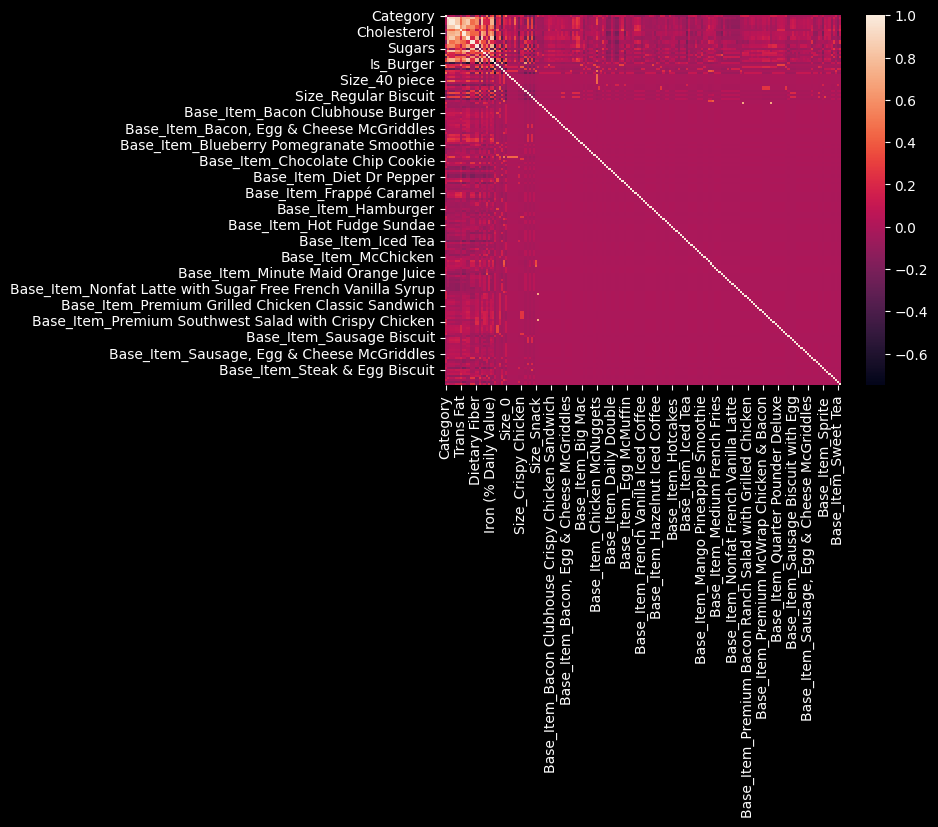

In [32]:
sns.heatmap(df.corr(method='pearson'))

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X = df.drop('Calories',axis=1)
y = df['Calories']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.9956974942041196

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

In [38]:
y_pred = model.predict(X_test)

In [39]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 177.86895491225812
,RMSE: 13.33675203759364
,R²: 0.9956974942041196
